# Transformer Fault Diagnosis via DGA + ML
Classical methods (IEC 60599 Basic Gas Ratio, Duval Triangle) benchmarked against a Random Forest classifier on the same Dissolved Gas Analysis (DGA) data.

## 1. Imports

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.path import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score

## 2. Load and clean data

In [ ]:
df = pd.read_excel("../data/IEEE_STANDARD.xlsx")
df = df.rename(columns={'故障类型': 'fault_type'})   # source column header ships in Chinese ("fault type")
print(df.columns.tolist())
print(df['fault_type'].value_counts())
print(df.isna().sum())

['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2', 'fault_type']
fault_type
D2    149
T1    111
T3    104
D1     91
PD     74
T2     60
Name: count, dtype: int64
H2            0
CH4           0
C2H6          0
C2H4          0
C2H2          0
fault_type    0
dtype: int64


## 3. Log-transform the gas columns
Raw values span 5 orders of magnitude, so we compress with log1p before doing anything else.

In [ ]:
gas_cols = ['H2', 'CH4', 'C2H6', 'C2H4', 'C2H2']
for col in gas_cols:
    df[f'log_{col}'] = np.log1p(df[col])
df[[f'log_{c}' for c in gas_cols]].describe()

,log_H2,log_CH4,log_C2H6,log_C2H4,log_C2H2
count,589.000000,589.000000,589.000000,589.000000,589.000000
mean,4.827886,4.428996,3.528601,4.065128,2.609058
std,2.098394,1.943938,1.920131,2.301070,2.636451
min,0.000100,0.000100,0.000100,0.000100,0.000100
25%,3.555348,3.091042,2.197225,2.397895,0.000100
50%,4.718499,4.219508,3.663562,3.951244,2.197225
75%,5.932245,5.488731,4.804021,5.700444,4.499810
max,11.436055,11.067653,11.186211,11.468461,10.950824


## 4. EDA: gas distributions by fault type


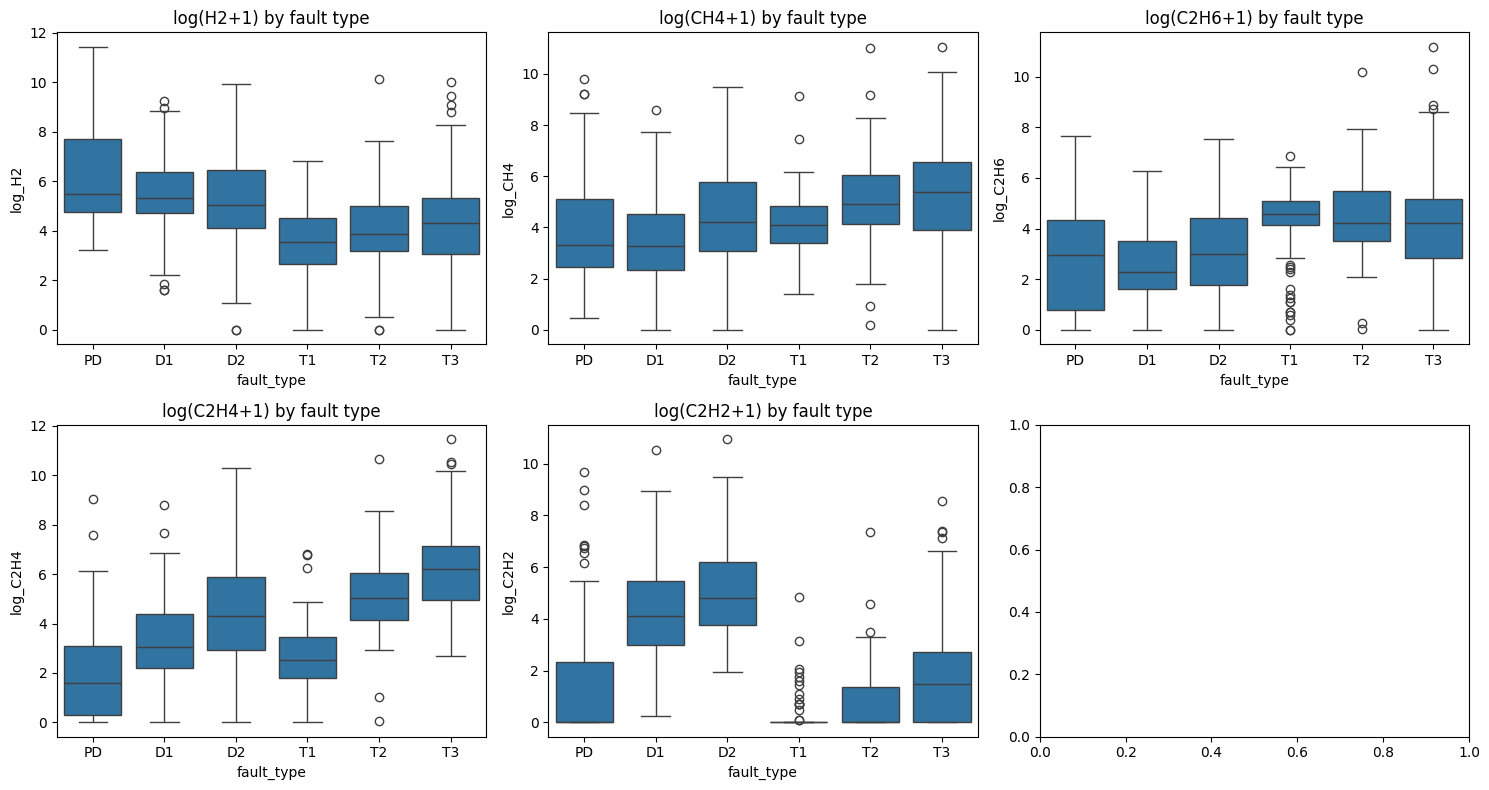

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(gas_cols):
    sns.boxplot(data=df, x='fault_type', y=f'log_{col}', ax=axes[i])
    axes[i].set_title(f'log({col}+1) by fault type')
plt.tight_layout()
plt.show()

## 5. Feature engineering
Combine log-transformed raw gases with the same ratio features the classical methods use.

In [ ]:
df['ratio_c2h2_c2h4'] = df['C2H2'] / df['C2H4'].replace(0, 0.0001)
df['ratio_ch4_h2'] = df['CH4'] / df['H2'].replace(0, 0.0001)
df['ratio_c2h4_c2h6'] = df['C2H4'] / df['C2H6'].replace(0, 0.0001)

feature_cols = [f'log_{c}' for c in gas_cols] + ['ratio_c2h2_c2h4', 'ratio_ch4_h2', 'ratio_c2h4_c2h6']
X = df[feature_cols]
y = df['fault_type']
print(X.shape)

(589, 8)


## 6. PCA visualization
Scale first (PCA is scale-sensitive), then reduce to 2D to see whether fault classes separate.

Variance explained by PC1, PC2: [0.35650315 0.16902357]


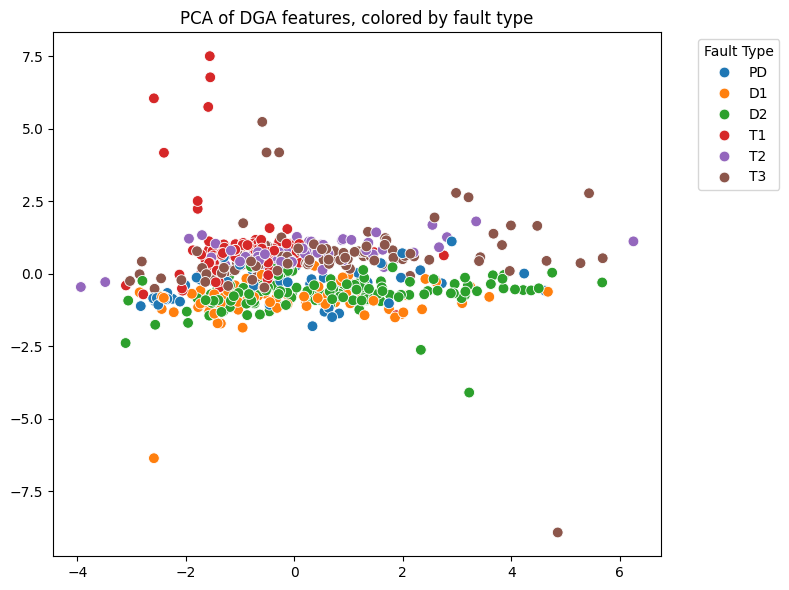

In [ ]:
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Variance explained by PC1, PC2:", pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10', s=60)
plt.title('PCA of DGA features, colored by fault type')
plt.legend(title='Fault Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7. Train and evaluate the ML model
Stratified 5-fold cross-validation so every prediction is on unseen data. Confusion matrix shows exactly which classes get confused, not just an accuracy number.

              precision    recall  f1-score   support

          D1       0.69      0.63      0.66        91
          D2       0.79      0.87      0.83       149
          PD       0.86      0.76      0.81        74
          T1       0.87      0.87      0.87       111
          T2       0.77      0.77      0.77        60
          T3       0.90      0.91      0.90       104

    accuracy                           0.82       589
   macro avg       0.81      0.80      0.81       589
weighted avg       0.82      0.82      0.82       589



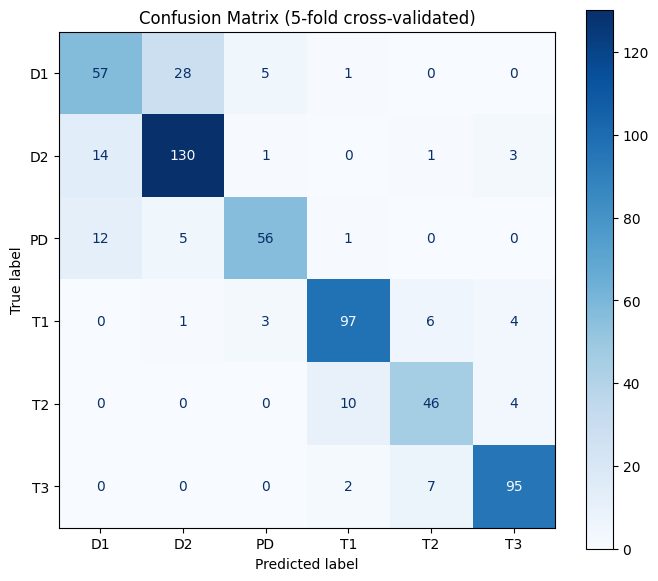

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestClassifier(n_estimators=200, random_state=42)
y_pred = cross_val_predict(model, X, y, cv=skf)

print(classification_report(y, y_pred))

labels_order = sorted(y.unique())
cm = confusion_matrix(y, y_pred, labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (5-fold cross-validated)')
plt.show()

## 8. Feature importance
Check whether the model independently learned that the gas ratios matter most -- the same signal the classical methods are built on.

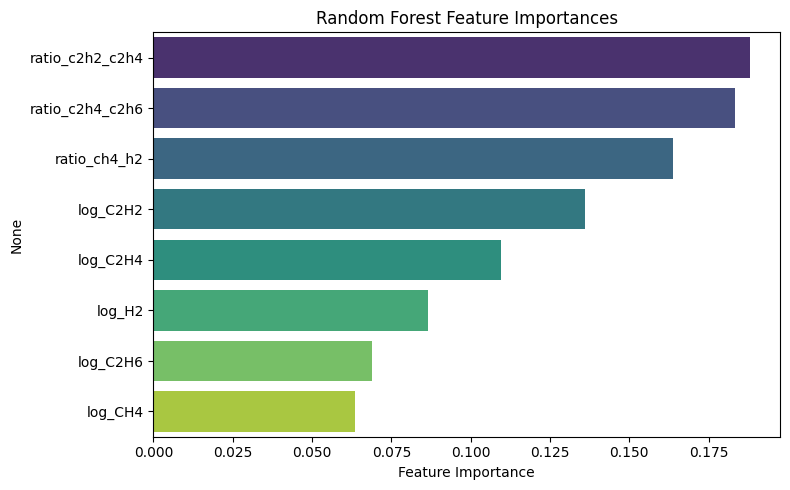

ratio_c2h2_c2h4    0.188095
ratio_c2h4_c2h6    0.183387
ratio_ch4_h2       0.163763
log_C2H2           0.135894
log_C2H4           0.109533
log_H2             0.086707
log_C2H6           0.069026
log_CH4            0.063595
dtype: float64


In [ ]:
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()
print(importances)

## 9. Predicting on a new sample

In [ ]:
def predict_fault(h2, ch4, c2h6, c2h4, c2h2, model, feature_cols):
    """Score one new DGA reading with the trained Random Forest.

    Builds the same 8 features used at training time (5 log-transformed
    gases + 3 domain ratios) from raw ppm values, then returns both the
    single best-guess label and the full per-class probability breakdown.
    """
    new_sample = pd.DataFrame([{
        'log_H2': np.log1p(h2), 'log_CH4': np.log1p(ch4), 'log_C2H6': np.log1p(c2h6),
        'log_C2H4': np.log1p(c2h4), 'log_C2H2': np.log1p(c2h2),
        'ratio_c2h2_c2h4': c2h2 / (c2h4 if c2h4 != 0 else 0.0001),
        'ratio_ch4_h2': ch4 / (h2 if h2 != 0 else 0.0001),
        'ratio_c2h4_c2h6': c2h4 / (c2h6 if c2h6 != 0 else 0.0001),
    }])[feature_cols]   # reselect by NAME -- sklearn matches columns by position, not name
    prediction = model.predict(new_sample)[0]
    probabilities = model.predict_proba(new_sample)[0]
    return prediction, dict(zip(model.classes_, probabilities))

pred, probs = predict_fault(h2=2000, ch4=50, c2h6=10, c2h4=20, c2h2=100, model=model, feature_cols=feature_cols)
print("Predicted fault:", pred)
print("Confidence per class:", probs)

Predicted fault: D1
Confidence per class: {'D1': np.float64(0.6808333333333333), 'D2': np.float64(0.05666666666666667), 'PD': np.float64(0.2625), 'T1': np.float64(0.0), 'T2': np.float64(0.0), 'T3': np.float64(0.0)}


## 10. Duval Triangle -- working implementation
Zone polygon coordinates sourced from a verified, published DGA Python library (`duvals-triangle-plotter`), not hand-transcribed from an image -- a wrong boundary here would silently break the benchmark. Uses CH4, C2H4, C2H2 only (H2 and C2H6 aren't part of this method).

In [ ]:
def bary_to_xy(a, b, c):
    """Convert ternary coordinates (a=%CH4, b=%C2H2, c=%C2H4, summing to ~100)
    into 2D cartesian coordinates on an equilateral triangle, for point-in-polygon testing.
    """
    total = a + b + c
    a, b, c = a/total, b/total, c/total
    x = 0.5*(2*b + c)
    y = (np.sqrt(3)/2)*c
    return x, y

# Seven standard Duval zones, defined as (a=%CH4, b=%C2H2, c=%C2H4) polygon vertices.
# DT = mixed electrical/thermal fault -- not one of this dataset's 6 classes, reported separately.
duval_zones = {
    'PD': {'a':[98,1,98], 'b':[0,0,2], 'c':[2,0,0]},
    'D1': {'a':[0,0,64,87], 'b':[1,77,13,13], 'c':[0,23,23,0]},
    'D2': {'a':[0,0,31,47,64], 'b':[77,29,29,13,13], 'c':[23,71,40,40,23]},
    'DT': {'a':[0,0,35,46,96,87,47,31], 'b':[29,15,15,4,4,13,13,29], 'c':[71,85,50,50,0,0,40,40]},
    'T1': {'a':[76,80,98,98,96], 'b':[4,0,0,2,4], 'c':[20,20,2,0,0]},
    'T2': {'a':[46,50,80,76], 'b':[4,0,0,4], 'c':[50,50,20,20]},
    'T3': {'a':[0,0,50,35], 'b':[15,0,0,15], 'c':[85,1,50,50]},
}
duval_paths = {name: Path([bary_to_xy(a,b,c) for a,b,c in zip(z['a'], z['b'], z['c'])])
               for name, z in duval_zones.items()}

def duval_triangle(ch4, c2h4, c2h2):
    """Classify one DGA reading using the Duval Triangle.

    Normalizes CH4/C2H4/C2H2 to percentages of their sum, converts to a
    2D point, and returns whichever of the 7 standard zones contains it.
    Falls back to the nearest zone centroid on a rounding/boundary edge case.
    """
    total = ch4 + c2h4 + c2h2
    if total == 0:
        return None
    x, y = bary_to_xy(100*ch4/total, 100*c2h2/total, 100*c2h4/total)
    for name, path in duval_paths.items():
        if path.contains_point((x, y)):
            return name
    best, bestd = None, float('inf')
    for name, path in duval_paths.items():
        cx, cy = path.vertices[:,0].mean(), path.vertices[:,1].mean()
        d = (cx-x)**2 + (cy-y)**2
        if d < bestd:
            bestd, best = d, name
    return best

df['duval_pred'] = df.apply(lambda r: duval_triangle(r['CH4'], r['C2H4'], r['C2H2']), axis=1)
df['duval_pred'].value_counts(dropna=False)

duval_pred
T3    138
D1    126
D2    114
T2     84
T1     68
PD     33
DT     26
Name: count, dtype: int64

## 11. IEC 60599 Basic Gas Ratio method -- working implementation
The modern, IEC-adopted descendant of the 1978 Rogers Ratio table -- and the version whose 6 output categories actually line up with this dataset's fault classes (plain Rogers doesn't cleanly separate PD/D1/D2). Source: IEC 60599-2007 / IEEE C57.104 reference table.

In [ ]:
def iec_ratio_method(h2, ch4, c2h6, c2h4, c2h2):
    """Classify one DGA reading using the IEC 60599 Basic Gas Ratio table.

    Computes the 3 diagnostic ratios (C2H2/C2H4, CH4/H2, C2H4/C2H6) and
    matches them against the standard's 6 fault-type ranges in order.
    Returns None when the ratio combination isn't covered by any row of
    the table -- this happens for real, and is exactly the coverage gap
    the benchmark section measures.
    """
    r_c2h2_c2h4 = c2h2/c2h4 if c2h4 != 0 else float('inf')
    r_ch4_h2 = ch4/h2 if h2 != 0 else float('inf')
    r_c2h4_c2h6 = c2h4/c2h6 if c2h6 != 0 else float('inf')

    if r_ch4_h2 < 0.1 and r_c2h4_c2h6 < 0.2:
        return 'PD'
    if r_c2h2_c2h4 > 1.0 and 0.1 <= r_ch4_h2 <= 0.5 and r_c2h4_c2h6 > 1.0:
        return 'D1'
    if 0.6 <= r_c2h2_c2h4 <= 2.5 and 0.1 <= r_ch4_h2 <= 1.0 and r_c2h4_c2h6 > 2.0:
        return 'D2'
    if r_ch4_h2 > 1.0 and r_c2h4_c2h6 < 1.0:
        return 'T1'
    if r_c2h2_c2h4 < 0.1 and r_ch4_h2 > 1.0 and 1.0 <= r_c2h4_c2h6 <= 4.0:
        return 'T2'
    if r_c2h2_c2h4 < 0.2 and r_ch4_h2 > 1.0 and r_c2h4_c2h6 > 4.0:
        return 'T3'
    return None

df['iec_pred'] = df.apply(lambda r: iec_ratio_method(r['H2'], r['CH4'], r['C2H6'], r['C2H4'], r['C2H2']), axis=1)
df['iec_pred'].value_counts(dropna=False)

iec_pred
None    212
D1      110
T3       85
T1       75
T2       60
D2       24
PD       23
Name: count, dtype: int64

## 12. The benchmark -- classical methods vs. ML
This comparison, not the bare 82% accuracy number, is the actual thesis of the project: does a learned model beat the rules engineers use by hand, and if so, where specifically?

In [ ]:
valid_classes = set(y.unique())   # {'PD','D1','D2','T1','T2','T3'} -- this dataset's 6 labels

def evaluate(name, pred_col):
    """Print coverage and accuracy/F1 for one classical method's prediction column.

    'Coverage' = how many of the 589 rows the method mapped to one of
    this dataset's 6 actual fault classes. This deliberately excludes
    two different flavors of "not a usable answer": IEC returns None
    when no rule in the table matches, and Duval's DT zone (mixed
    thermal/electrical fault) is a real zone but not one of the 6
    classes here, so it can never be scored correct either. Accuracy is
    reported two ways: only on the rows the method actually covered, and
    over all 589 rows with everything else counted as wrong -- the
    second number is the fair, apples-to-apples comparison against the
    ML model below, which always outputs one of the 6 classes.
    """
    covered = df[pred_col].isin(valid_classes)
    filled = df[pred_col].where(covered, 'NO_MATCH')
    coverage = covered.sum()
    acc_all = accuracy_score(df['fault_type'], filled)
    acc_covered = accuracy_score(df.loc[covered,'fault_type'], df.loc[covered,pred_col]) if coverage else float('nan')
    f1_covered = f1_score(df.loc[covered,'fault_type'], df.loc[covered,pred_col], average='macro') if coverage else float('nan')
    print(f"{name:20s} | coverage: {coverage}/{len(df)} | acc (all rows): {acc_all:.3f} | acc (covered only): {acc_covered:.3f} | macro F1 (covered): {f1_covered:.3f}")

evaluate("IEC 60599 Ratio", "iec_pred")
evaluate("Duval Triangle", "duval_pred")

# ML numbers come from the cross-validated run in Section 7 (recomputed here for a single summary line)
ml_acc = accuracy_score(y, y_pred)
ml_f1 = f1_score(y, y_pred, average='macro')
print(f"{'Random Forest (ML)':20s} | coverage: {len(df)}/{len(df)} | acc (all rows): {ml_acc:.3f} | acc (covered only): -- | macro F1 (covered): {ml_f1:.3f}")

IEC 60599 Ratio      | coverage: 377/589 | acc (all rows): 0.467 | acc (covered only): 0.729 | macro F1 (covered): 0.725
Duval Triangle       | coverage: 563/589 | acc (all rows): 0.628 | acc (covered only): 0.657 | macro F1 (covered): 0.629
Random Forest (ML)   | coverage: 589/589 | acc (all rows): 0.817 | acc (covered only): -- | macro F1 (covered): 0.806


### Per-class breakdown for the two classical methods
Same idea as the confusion matrix in Section 7 -- an aggregate accuracy number hides *where* each method actually struggles.

In [ ]:
print("=== IEC 60599 Ratio -- classified rows only ===")
print(classification_report(df.loc[covered_iec := df['iec_pred'].isin(valid_classes), 'fault_type'],
                             df.loc[covered_iec, 'iec_pred']))

print("=== Duval Triangle -- classified rows only (excludes DT, the mixed-fault zone) ===")
print(classification_report(df.loc[covered_duval := df['duval_pred'].isin(valid_classes), 'fault_type'],
                             df.loc[covered_duval, 'duval_pred']))

=== IEC 60599 Ratio -- classified rows only ===
              precision    recall  f1-score   support

          D1       0.39      0.88      0.54        49
          D2       1.00      0.25      0.40        95
          PD       0.74      0.74      0.74        23
          T1       0.84      0.90      0.87        70
          T2       0.85      0.96      0.90        53
          T3       0.91      0.89      0.90        87

    accuracy                           0.73       377
   macro avg       0.79      0.77      0.73       377
weighted avg       0.83      0.73      0.71       377

=== Duval Triangle -- classified rows only (excludes DT, the mixed-fault zone) ===
              precision    recall  f1-score   support

          D1       0.52      0.78      0.62        83
          D2       0.82      0.65      0.73       144
          PD       0.85      0.42      0.56        67
          T1       0.81      0.51      0.62       108
          T2       0.36      0.51      0.42        59
 